In [1]:
from cirq_sic import *

## Simple WH-POVM with midcircuit measurement

\begin{align}
P(R_{ij}) &= \frac{1}{d}|\langle \phi |D_{ij}^\dagger |\psi\rangle|^2 = \frac{1}{d}|\langle D_{ij}|\psi, \phi^*\rangle|^2\\
&= \frac{1}{d}\left|\langle i, j|(I \otimes F^\dagger)\left(\sum_q X^{-q} \otimes |q\rangle\langle q|\right)|\psi, \phi^*\rangle \right|\\
&= \frac{1}{d}\left|\langle i, j|(F^\dagger \otimes F^\dagger)\left(\sum_q Z^{-q} \otimes |q\rangle\langle q|\right)(F \otimes I)|\psi, \phi^*\rangle \right|
\end{align}

So we should be able to use midcircuit measurement to deal with the final two QFTs!

In [2]:
d = 4
n = int(np.log2(d))
qubits = get_wh_qubits(d, "simple")
phi = load_sic_fiducial(d)
ket = rand_ket(d)
system_qubits = qubits[:n]
fiducial_qubits = qubits[n:2*n]
prepare_system = ansatz_circuit(ket)
prepare_fiducial = ansatz_circuit(phi)
circ = cirq.Circuit((prepare_system(system_qubits),\
                     msimple_wh_povm(system_qubits, fiducial_qubits, prepare_fiducial=prepare_fiducial)))
print(circ)            

                                                                                                                                   ┌─────────┐               ┌──┐   ┌────────┐
(4, 2): ───Rz(0.13π)────Ry(0.622π)───Rz(-0.646π)───@─────────────────@────────────────@────────────────@───H───@───────────×────────@────────────@───×───────────────S^-1────────H───M('s_0')───
                                                   │                 │                │                │       │           │        │            │   │               ║
(4, 3): ───Ry(0.725π)──────────────────────────────X───Ry(-0.169π)───X───Rz(0.288π)───X───Rz(0.68π)────X───────@^0.5───H───×───@────┼──@─────────┼───×───H────M──────╫──────────────────────────
                                                                                                                               │    │  │         │            ║      ║
(5, 2): ───Rz(-1.63π)───Ry(0.566π)───Rz(-0.133π)───@─────────────────@────────────────@────────────────@─

In [3]:
N = 1000
simulator = cirq.Simulator()
result = simulator.run(circ, repetitions=N)
keys = [f"s_{i}" for i in range(n)] + [f"a_{i}" for i in range(n)]
hist = result.multi_measurement_histogram(keys=keys)
p = np.array([
    hist.get(tuple(map(int, f"{i:0{2*n}b}")), 0) / N
    for i in range(d**2)
])

In [4]:
p_theory = np.array([abs(phi.conj() @ O.conj().T @ ket)**2 for O in wh_operators(d)["D"].reshape(d**2, d, d)])/d
p_theory

array([0.216, 0.076, 0.103, 0.042, 0.019, 0.079, 0.013, 0.035, 0.038,
       0.085, 0.053, 0.044, 0.035, 0.005, 0.083, 0.074])

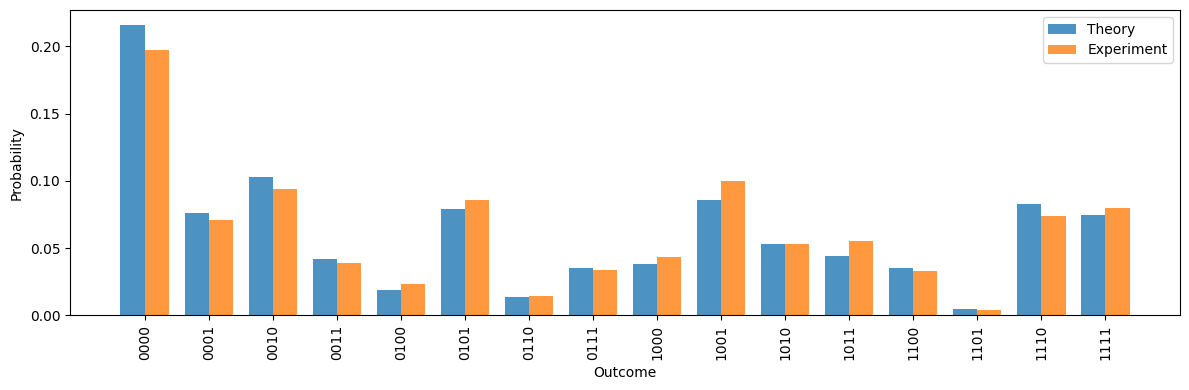

In [5]:
x = np.arange(len(p)) 
width = 0.38
plt.figure(figsize=(12, 4))
plt.bar(x - width/2, p_theory, width=width, label="Theory", alpha=0.8)
plt.bar(x + width/2, p,        width=width, label="Experiment", alpha=0.8)

plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.xticks(x, [f"{i:0{2*n}b}" for i in x], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()